# Exploratory Data Analysis Section

This notebook will use PyAthena to query a AWS Glue database table that contains the raw information then perform Exploratory Data Analysis.

In [4]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [5]:
# read in the csv data file into a pandas dataframe
raw_df = pd.read_csv("C:/Users/graha/Documents/MS Applied Data Science/ADS_508_Data_Science_with_Cloud_Computing/ADS-508-Project/2_raw_data/raw_merged/raw_merged_data.csv")

In [6]:
# Get shape of the data
raw_df.shape

(185600, 21)

In [7]:
# Get a list of the column names
raw_df.columns

Index(['FL_DATE', 'CRS_DEP_TIME', 'DEP_TIME', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_FL_NUM', 'DEST', 'DEP_DEL15', 'CANCELLED',
       'CANCELLATION_CODE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
       'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'wind_dir_degrees',
       'wind_speed_kt', 'wind_gust_kt', 'visibility_statute_mi',
       'temperature_c', 'dewpoint_c', 'altimeter_hpa'],
      dtype='object')

In [8]:
# get information on the df
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185600 entries, 0 to 185599
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   FL_DATE                185600 non-null  object 
 1   CRS_DEP_TIME           185600 non-null  object 
 2   DEP_TIME               183548 non-null  object 
 3   OP_UNIQUE_CARRIER      185600 non-null  object 
 4   OP_CARRIER_FL_NUM      185600 non-null  int64  
 5   DEST                   185600 non-null  object 
 6   DEP_DEL15              185600 non-null  int64  
 7   CANCELLED              185600 non-null  int64  
 8   CANCELLATION_CODE      2118 non-null    object 
 9   CARRIER_DELAY          185600 non-null  int64  
 10  WEATHER_DELAY          185600 non-null  int64  
 11  NAS_DELAY              185600 non-null  int64  
 12  SECURITY_DELAY         185600 non-null  int64  
 13  LATE_AIRCRAFT_DELAY    185600 non-null  int64  
 14  wind_dir_degrees       170031 non-nu

In [9]:
# get number of nulls in each column
raw_df.isnull().sum()

FL_DATE                       0
CRS_DEP_TIME                  0
DEP_TIME                   2052
OP_UNIQUE_CARRIER             0
OP_CARRIER_FL_NUM             0
DEST                          0
DEP_DEL15                     0
CANCELLED                     0
CANCELLATION_CODE        183482
CARRIER_DELAY                 0
WEATHER_DELAY                 0
NAS_DELAY                     0
SECURITY_DELAY                0
LATE_AIRCRAFT_DELAY           0
wind_dir_degrees          15569
wind_speed_kt                 0
wind_gust_kt                  0
visibility_statute_mi         0
temperature_c                 0
dewpoint_c                    0
altimeter_hpa                 0
dtype: int64

In [10]:
# get summary statistics of the dataframe
raw_df.describe()

,OP_CARRIER_FL_NUM,DEP_DEL15,CANCELLED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,wind_dir_degrees,wind_speed_kt,wind_gust_kt,visibility_statute_mi,temperature_c,dewpoint_c,altimeter_hpa
count,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,170031.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000
mean,1992.292236,0.095264,0.011412,3.595609,0.565388,3.030501,0.022328,6.407473,210.329940,5.555167,1.506606,9.548665,18.208988,11.916069,29.999487
std,1281.470818,0.293580,0.106214,33.489037,12.527305,15.422100,1.125169,31.559910,118.023751,3.311657,5.157662,1.415645,4.018744,5.143698,0.104090
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,-17.800000,-17.800000,29.450000
25%,894.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,3.000000,0.000000,10.000000,15.600000,8.900000,29.930000
50%,1939.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,270.000000,6.000000,0.000000,10.000000,18.300000,12.800000,29.990000
75%,2924.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,8.000000,0.000000,10.000000,21.100000,16.100000,30.070000
max,8784.000000,1.000000,1.000000,3300.000000,1171.000000,1431.000000,276.000000,2100.000000,360.000000,22.000000,42.000000,10.000000,34.400000,22.800000,30.360000


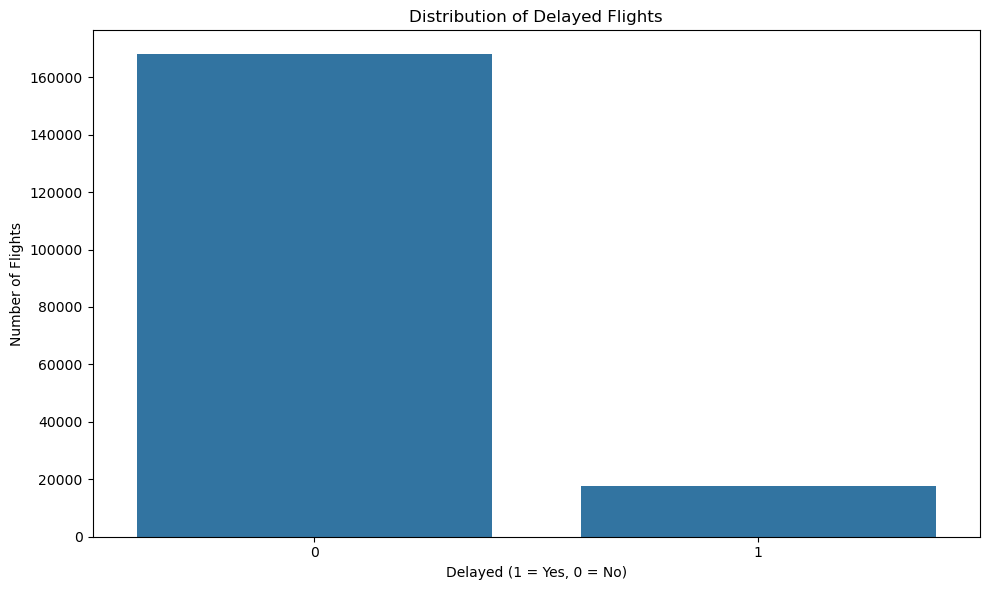

In [11]:
# visualize the distribution of delayed flights
plt.figure(figsize=(10,6))
sns.countplot(data=raw_df, x='DEP_DEL15')
plt.title('Distribution of Delayed Flights')
plt.xlabel('Delayed (1 = Yes, 0 = No)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

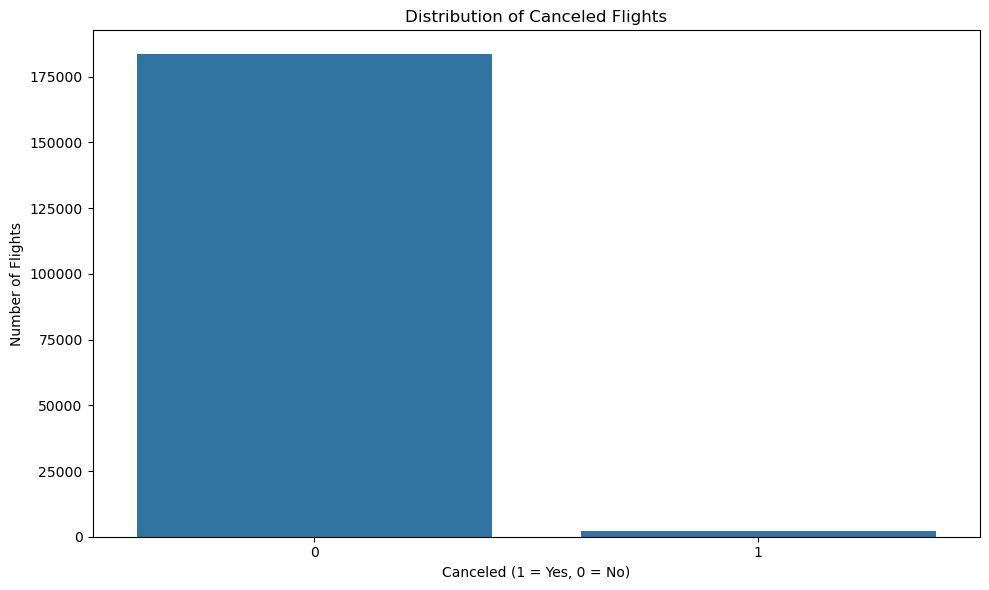

In [12]:
# visualize distribution of canceled flights
plt.figure(figsize=(10,6))
sns.countplot(data=raw_df, x='CANCELLED')
plt.title('Distribution of Canceled Flights')
plt.xlabel('Canceled (1 = Yes, 0 = No)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

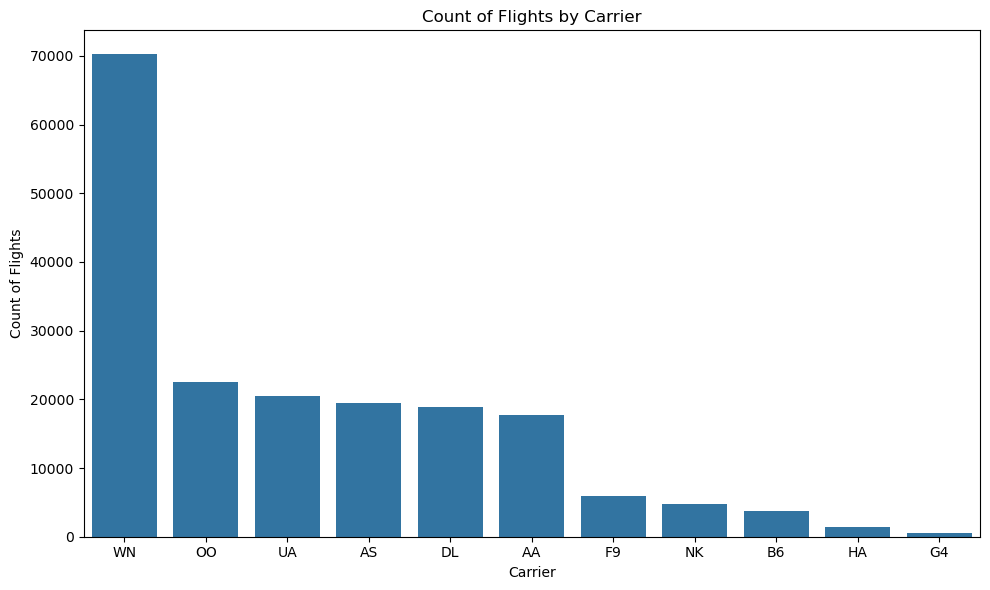

In [14]:
# explore the distribution of carriers and flights
# get count of flights by airline
carrier_counts = raw_df['OP_UNIQUE_CARRIER'].value_counts().reset_index()
carrier_counts.columns = ['Carrier', 'Count of Flights']

# plot the count of flights by airline
plt.figure(figsize=(10,6))
sns.barplot(data=carrier_counts, x='Carrier', y='Count of Flights')
plt.title('Count of Flights by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Count of Flights')
plt.tight_layout()
plt.show()

In [15]:
# create new category in dataframe for eda
raw_eda_df = raw_df.copy()

In [18]:
"""
Funciton that will categorize Canceled, Delayed, and On-Time flights
"""
def classify_fl_status(row):
    if row['CANCELLED'] == 1:
        return 'Cancelled'
    elif row['DEP_DEL15'] == 1:
        return 'Delayed'
    else:
        return 'On-Time'

  Flight_Status   count
0       On-Time  165811
1       Delayed   17671
2     Cancelled    2118
  Flight_Status   count  Percentage
0       On-Time  165811   89.337823
1       Delayed   17671    9.521013
2     Cancelled    2118    1.141164


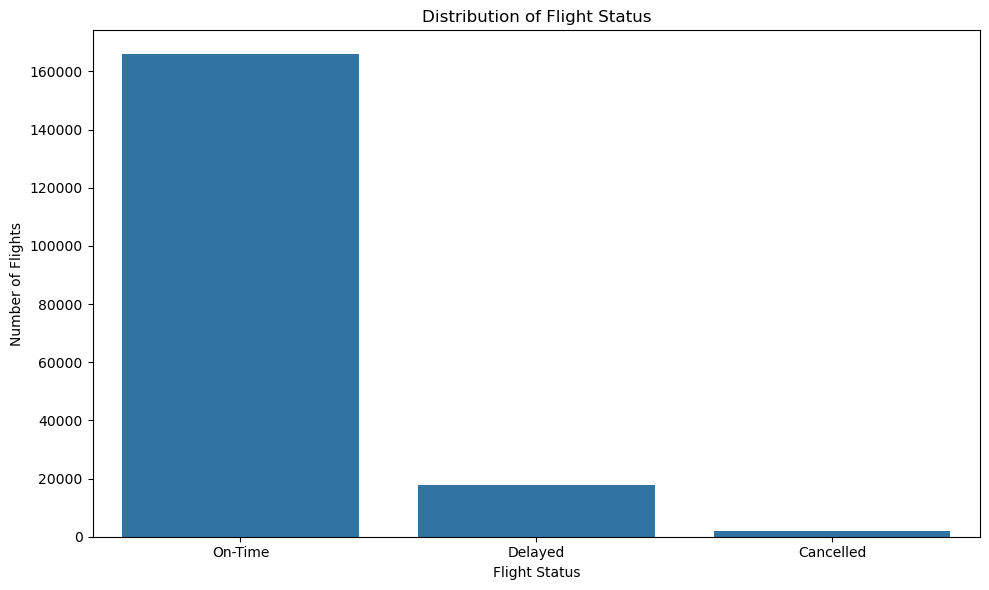

In [ ]:
# create the new column in the dataframe by applying the function
raw_eda_df['Flight_Status'] = raw_eda_df.apply(classify_fl_status, axis=1)

# get the counts of the flight status column
fl_status_counts = raw_eda_df['Flight_Status'].value_counts().reset_index()
# print(fl_status_counts)

# print the percentage of each flight status
fl_status_counts['Percentage'] = (fl_status_counts['count'] / fl_status_counts['count'].sum()) * 100
print(fl_status_counts)

# visualize the distribution of flight status
plt.figure(figsize=(10,6))
sns.countplot(data=raw_eda_df, x='Flight_Status')
plt.title('Distribution of Flight Status')
plt.xlabel('Flight Status')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

## skip this section and only work above on the EDA (this is the failed trying to read in from the database)


#set parameters for athena connection
region_name = "us-east-1"
s3_staging_dir = "s3://group9-ml-proj-raw-data-bucket-grw/queries/"


#establish connection
conn = connect(s3_staging_dir=s3_staging_dir, region_name=region_name)
cursor = conn.cursor()

#query the glue table
query = """
    SELECT * 
    FROM raw_data.raw_merged_data_csv
    """


#read the query into a pandas dataframe
raw_df = pd.read_sql(query, conn)

#print head of the df
raw_df.head()

In [7]:
%%html
<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>